# Predictive Maintenance — NBI Bridge Condition Classification
**Models:** Logistic Regression · Naive Bayes · Random Forest · LightGBM · LinearSVC · SVM-RBF (sampled)

**Target:** `TARGET_CONDITION` → {Critical, Poor, Fair, Good} (4-class ordinal)

---
**Pipeline overview**
1. Load & inspect
2. Feature selection & preprocessing
3. Train/test split + class imbalance handling (SMOTE)
4. Model training — Family A, B, C
5. Evaluation — Macro F1, ROC-AUC, confusion matrix, calibration
6. SHAP interpretability (tree models)
7. Results summary table

## 0 — Install dependencies

In [3]:
# Upgrade all packages to versions that support NumPy 2.x
!pip install -q --upgrade \
    "scikit-learn>=1.5" \
    "lightgbm>=4.3" \
    "imbalanced-learn>=0.12" \
    "shap>=0.46" \
    "pyarrow>=16.0" \
    pandas matplotlib seaborn


## 1 — Imports & configuration

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Family A — Classical
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Family B — Tree-based
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb

# Family C — Margin / kernel
from sklearn.svm import LinearSVC, SVC

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

print('All imports OK')

All imports OK


## 2 — Load data

In [5]:
DATA_PATH = '/Users/akash/dev/DATA245/Project/nbi_cleaned.parquet'   # parquet from EDA step

df = pd.read_parquet(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['TARGET_CONDITION'].value_counts())
print(f'\nClass balance (%):')
print((df['TARGET_CONDITION'].value_counts(normalize=True) * 100).round(2))

Shape: (1999950, 128)

Target distribution:
TARGET_CONDITION
Fair        285676
Good        283316
Poor         35022
Critical     12032
Name: count, dtype: int64

Class balance (%):
TARGET_CONDITION
Fair        46.37
Good        45.99
Poor         5.68
Critical     1.95
Name: proportion, dtype: float64


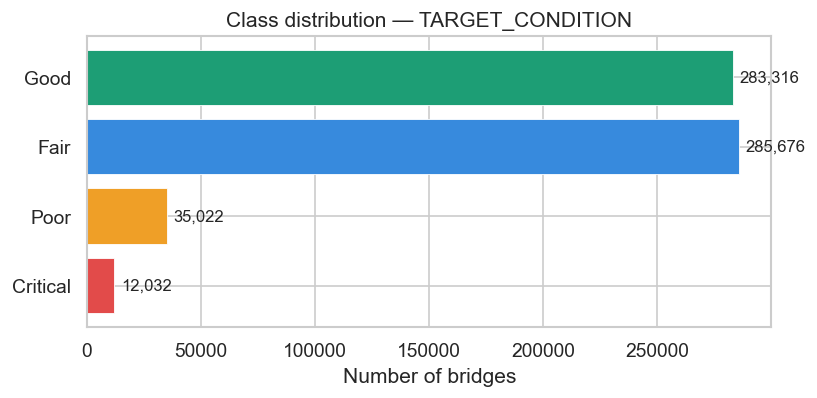

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
order = ['Critical', 'Poor', 'Fair', 'Good']
counts = df['TARGET_CONDITION'].value_counts().reindex(order)
colors = ['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75']
bars = ax.barh(order, counts.values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + counts.max() * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.set_xlabel('Number of bridges')
ax.set_title('Class distribution — TARGET_CONDITION')
plt.tight_layout()
plt.show()

## 3 — Feature selection & preprocessing

In [7]:
# ── Columns to drop ────────────────────────────────────────────────────────────
# TARGET_NUM is the numeric version of TARGET_CONDITION — leakage
# Free-text / ID columns that carry no signal
DROP_COLS = [
    'TARGET_CONDITION', 'TARGET_NUM',          # target (one kept as y)
    'OTHR_STATE_STRUC_NO_099',                 # free-text bridge ID
    'PROJ_NO', 'PROJ_SUFFIX', 'PROGRAM_CODE',  # admin codes
    'SUFFICIENCY_ASTERC',                      # flag derived from target
    'NBI_TYPE_OF_IMP', 'DTL_TYPE_OF_IMP',      # work codes — post-inspection
    'YEAR',                                    # dataset year, not a bridge feature
]

TARGET_COL = 'TARGET_CONDITION'

# ── Separate X and y ───────────────────────────────────────────────────────────
y_raw = df[TARGET_COL].copy()
X_raw = df.drop(columns=DROP_COLS, errors='ignore')

print(f'Features: {X_raw.shape[1]}')
print(f'Target classes: {sorted(y_raw.unique())}')

Features: 122


TypeError: '<' not supported between instances of 'float' and 'str'

In [ ]:
# ── Encode target ──────────────────────────────────────────────────────────────
# Ordered: Critical=0, Poor=1, Fair=2, Good=3
CLASS_ORDER = ['Critical', 'Poor', 'Fair', 'Good']
class_to_int = {c: i for i, c in enumerate(CLASS_ORDER)}
int_to_class = {i: c for i, c in enumerate(CLASS_ORDER)}

y = y_raw.map(class_to_int).values

if any(v != v for v in y):  # NaN check
    raise ValueError('y contains NaN — unknown class labels in TARGET_CONDITION')

print('Label mapping:', class_to_int)
print('Encoded y sample:', y[:10])


In [ ]:
# ── Step 1: Drop columns that are entirely NaN (carry zero signal) ────────────
X = X_raw.copy()
all_nan_cols = X.columns[X.isnull().all()].tolist()
X.drop(columns=all_nan_cols, inplace=True)
print(f'Dropped all-NaN columns ({len(all_nan_cols)}): {all_nan_cols}')

# ── Step 2: Encode object columns ─────────────────────────────────────────────
# Strip whitespace BEFORE encoding — padded strings like 'A  ' cause NaN in codes
obj_cols = X.select_dtypes(include='object').columns.tolist()
print(f'\nObject columns to encode ({len(obj_cols)}): {obj_cols[:15]}')

for col in obj_cols:
    X[col] = X[col].astype(str).str.strip()   # strip whitespace first
    n_unique = X[col].nunique()
    if n_unique <= 50:
        X[col] = pd.Categorical(X[col]).codes  # NaN → -1
    else:
        X.drop(columns=[col], inplace=True)

# ── Step 3: Fill ALL remaining NaNs with column median ────────────────────────
# This must happen BEFORE the train/test split so SMOTE never sees NaN
num_cols = X.select_dtypes(include='number').columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# ── Step 4: Verify zero NaNs ───────────────────────────────────────────────────
remaining_nans = X.isnull().sum().sum()
print(f'\nNaN cells remaining: {remaining_nans}')   # must be 0
assert remaining_nans == 0, 'Still have NaNs — check encoding steps above'

# ── Step 5: Remove near-zero variance & highly correlated features ─────────────
var_thresh = X.var()
low_var = var_thresh[var_thresh < 1e-6].index.tolist()
X.drop(columns=low_var, inplace=True)

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.90)]
X.drop(columns=high_corr_cols, inplace=True)

print(f'\nFinal feature count after cleaning: {X.shape[1]}')
print(f'Dropped — all-NaN: {len(all_nan_cols)}, low-variance: {len(low_var)}, high-corr: {len(high_corr_cols)}')

## 4 — Train / test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print('Train class counts:', dict(zip(*np.unique(y_train, return_counts=True))))

In [ ]:
# ── Scale features (needed for LR, NB, SVM) ────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── SMOTE on training set only ─────────────────────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print('After SMOTE:')
print(dict(zip(*np.unique(y_train_sm, return_counts=True))))

## 5 — Helper: evaluation function

In [ ]:
RESULTS = {}  # collect all model results here

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te,
                   has_proba=True, class_names=None):
    """Fit, predict, and store metrics. Returns fitted model."""
    if class_names is None:
        class_names = CLASS_ORDER

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    macro_f1 = f1_score(y_te, y_pred, average='macro')
    per_class_f1 = f1_score(y_te, y_pred, average=None)

    roc_auc = None
    brier = None
    if has_proba:
        y_prob = model.predict_proba(X_te)
        roc_auc = roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro')
        # Brier score averaged over classes
        from sklearn.preprocessing import label_binarize
        y_bin = label_binarize(y_te, classes=[0, 1, 2, 3])
        brier = np.mean([brier_score_loss(y_bin[:, i], y_prob[:, i]) for i in range(4)])

    RESULTS[name] = {
        'Macro F1':  round(macro_f1, 4),
        'ROC-AUC':   round(roc_auc, 4) if roc_auc else '—',
        'Brier':     round(brier, 4)  if brier  else '—',
        'F1 Critical': round(per_class_f1[0], 4),
        'F1 Poor':     round(per_class_f1[1], 4),
        'F1 Fair':     round(per_class_f1[2], 4),
        'F1 Good':     round(per_class_f1[3], 4),
    }

    print('\n' + '='*55)
    print(f'  {name}')
    print('='*55)
    print(f'  Macro F1 : {macro_f1:.4f}')
    if roc_auc: print(f'  ROC-AUC  : {roc_auc:.4f}')
    if brier:   print(f'  Brier    : {brier:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=class_names))

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} — Confusion matrix')
    plt.tight_layout()
    plt.show()

    return model

print('evaluate_model() defined')

---
## 6 — Family A: Classical Baselines
### 6.1 — Logistic Regression (multinomial)

In [ ]:
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lr_fitted = evaluate_model(
    'Logistic Regression',
    lr,
    X_train_sm, y_train_sm,
    X_test_sc,  y_test,
    has_proba=True
)

In [ ]:
# Top feature coefficients per class
feature_names = X.columns.tolist()
coef_df = pd.DataFrame(
    lr_fitted.coef_,
    index=CLASS_ORDER,
    columns=feature_names
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, cls in zip(axes.flat, CLASS_ORDER):
    top = coef_df.loc[cls].abs().nlargest(12).index
    vals = coef_df.loc[cls, top]
    colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in vals]
    ax.barh(top, vals, color=colors, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='gray', linewidth=0.7)
    ax.set_title(f'Top coefficients — {cls}')
    ax.set_xlabel('Coefficient value')
plt.suptitle('Logistic Regression — Top 12 features per class', fontsize=13)
plt.tight_layout()
plt.show()

### 6.2 — Gaussian Naive Bayes

In [ ]:
gnb = GaussianNB(var_smoothing=1e-9)

gnb_fitted = evaluate_model(
    'Gaussian Naive Bayes',
    gnb,
    X_train_sm, y_train_sm,
    X_test_sc,  y_test,
    has_proba=True
)

---
## 7 — Family B: Tree-Based Models
### 7.1 — Random Forest

In [ ]:
# Note: tree models work on unscaled data and handle class imbalance natively
# We still apply SMOTE for a fair comparison, but use unscaled X

smote_raw = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm_raw, y_train_sm_raw = smote_raw.fit_resample(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_fitted = evaluate_model(
    'Random Forest',
    rf,
    X_train_sm_raw, y_train_sm_raw,
    X_test,         y_test,
    has_proba=True
)

In [ ]:
# Feature importance — Random Forest
feat_imp_rf = pd.Series(rf_fitted.feature_importances_, index=X.columns)
top20_rf = feat_imp_rf.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20_rf.sort_values().plot.barh(ax=ax, color='#378ADD', edgecolor='white', linewidth=0.4)
ax.set_title('Random Forest — Top 20 feature importances')
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

### 7.2 — LightGBM

In [ ]:
# Compute class weights for LightGBM
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train_sm_raw)

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    class_weight='balanced',
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1
)

lgbm_fitted = evaluate_model(
    'LightGBM',
    lgbm,
    X_train_sm_raw, y_train_sm_raw,
    X_test,         y_test,
    has_proba=True
)

In [ ]:
# Feature importance — LightGBM
feat_imp_lgb = pd.Series(
    lgbm_fitted.feature_importances_,
    index=X.columns
)
top20_lgb = feat_imp_lgb.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20_lgb.sort_values().plot.barh(ax=ax, color='#1D9E75', edgecolor='white', linewidth=0.4)
ax.set_title('LightGBM — Top 20 feature importances (gain)')
ax.set_xlabel('Feature importance (gain)')
plt.tight_layout()
plt.show()

---
## 8 — Family C: Margin / Kernel Methods
### 8.1 — LinearSVC (full dataset)

In [ ]:
# LinearSVC does not support predict_proba natively.
# Wrap in CalibratedClassifierCV to get probability estimates.
from sklearn.svm import LinearSVC

linear_svc_base = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=3000,
    random_state=RANDOM_STATE
)

linear_svc = CalibratedClassifierCV(
    linear_svc_base,
    method='isotonic',
    cv=3
)

lsvc_fitted = evaluate_model(
    'LinearSVC (calibrated)',
    linear_svc,
    X_train_sm, y_train_sm,
    X_test_sc,  y_test,
    has_proba=True
)

### 8.2 — SVM with RBF Kernel (stratified 50K sample)

In [ ]:
# RBF SVM is O(n²) in memory — train on a stratified 50K subsample
SAMPLE_SIZE = 50_000

# Subsample from the SMOTE-balanced training set
rng = np.random.default_rng(RANDOM_STATE)
if len(X_train_sm) > SAMPLE_SIZE:
    idx = rng.choice(len(X_train_sm), size=SAMPLE_SIZE, replace=False)
    X_rbf_train = X_train_sm[idx]
    y_rbf_train = y_train_sm[idx]
else:
    X_rbf_train = X_train_sm
    y_rbf_train = y_train_sm

print(f'RBF SVM training on {len(X_rbf_train):,} samples')
print('Class distribution in sample:', dict(zip(*np.unique(y_rbf_train, return_counts=True))))

In [ ]:
rbf_svc = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

rbf_fitted = evaluate_model(
    'SVM-RBF (50K sample)',
    rbf_svc,
    X_rbf_train, y_rbf_train,
    X_test_sc,   y_test,
    has_proba=True
)

---
## 9 — Probability Calibration (Platt / Isotonic)
Calibrate LR and NB — the two classical models most likely to be over/under-confident.

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

# Re-fit with Platt scaling calibration wrapper
models_to_calibrate = {
    'LR (Platt)': CalibratedClassifierCV(
        LogisticRegression(solver='lbfgs', max_iter=1000,
                           class_weight='balanced', C=1.0,
                           random_state=RANDOM_STATE, n_jobs=-1),
        method='sigmoid', cv=5
    ),
    'NB (Isotonic)': CalibratedClassifierCV(
        GaussianNB(),
        method='isotonic', cv=5
    ),
}

y_bin_test = label_binarize(y_test, classes=[0, 1, 2, 3])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (cal_name, cal_model) in zip(axes, models_to_calibrate.items()):
    cal_model.fit(X_train_sm, y_train_sm)
    y_cal_prob = cal_model.predict_proba(X_test_sc)

    for i, cls in enumerate(CLASS_ORDER):
        frac_pos, mean_pred = calibration_curve(
            y_bin_test[:, i], y_cal_prob[:, i], n_bins=10
        )
        ax.plot(mean_pred, frac_pos, marker='o', markersize=4, label=cls, linewidth=1.5)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.set_title(f'Calibration curve — {cal_name}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.legend(fontsize=9)

plt.suptitle('Reliability diagrams (calibration)', fontsize=13)
plt.tight_layout()
plt.show()


---
## 10 — SHAP Interpretability (Tree models)

In [ ]:
# Use a 5,000-row sample for SHAP (speed)
SHAP_SAMPLE = 5_000
shap_idx = np.random.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)
X_shap = X_test.iloc[shap_idx] if hasattr(X_test, 'iloc') else X_test[shap_idx]
X_shap_df = pd.DataFrame(X_shap, columns=X.columns)

print(f'SHAP sample size: {len(X_shap_df)}')

In [ ]:
# LightGBM SHAP (TreeExplainer — fast)
print('Computing SHAP values for LightGBM...')
explainer_lgb = shap.TreeExplainer(lgbm_fitted)
shap_values_lgb = explainer_lgb.shap_values(X_shap_df)

# Normalise: new SHAP (>=0.42) returns a 3-D array (samples, features, classes)
# older versions return a list of 2-D arrays — handle both
if isinstance(shap_values_lgb, np.ndarray) and shap_values_lgb.ndim == 3:
    shap_values_lgb = [shap_values_lgb[:, :, i] for i in range(shap_values_lgb.shape[2])]

print(f'SHAP output shape per class: {shap_values_lgb[0].shape}')


In [ ]:
# Summary plots — one figure per class (plt.sca does not work with SHAP)
for i, cls in enumerate(CLASS_ORDER):
    print(f"SHAP bar — {cls}")
    shap.summary_plot(
        shap_values_lgb[i], X_shap_df,
        plot_type='bar',
        max_display=15,
        show=False,
        color='#1D9E75'
    )
    plt.title(f'SHAP — LightGBM | Class: {cls}', fontsize=12)
    plt.tight_layout()
    plt.show()


In [ ]:
# Beeswarm for Critical class (most safety-critical)
print('SHAP beeswarm — Critical class')
shap.summary_plot(
    shap_values_lgb[0],   # index 0 = Critical
    X_shap_df,
    max_display=20,
    show=True
)

In [ ]:
# Random Forest SHAP
print('Computing SHAP values for Random Forest...')
explainer_rf = shap.TreeExplainer(rf_fitted)
shap_values_rf = explainer_rf.shap_values(X_shap_df)

# Normalise 3-D array if needed
if isinstance(shap_values_rf, np.ndarray) and shap_values_rf.ndim == 3:
    shap_values_rf = [shap_values_rf[:, :, i] for i in range(shap_values_rf.shape[2])]

shap.summary_plot(
    shap_values_rf[0],   # Critical class
    X_shap_df,
    max_display=15,
    show=True
)


---
## 11 — Safety-critical misclassification analysis
Key concern: how often does a model predict **Good** when the bridge is **Critical**?

In [ ]:
fitted_models = {
    'Logistic Regression':     (lr_fitted,    X_test_sc),
    'Gaussian Naive Bayes':    (gnb_fitted,   X_test_sc),
    'Random Forest':           (rf_fitted,    X_test.values if hasattr(X_test, 'values') else X_test),
    'LightGBM':                (lgbm_fitted,  X_test.values if hasattr(X_test, 'values') else X_test),
    'LinearSVC (calibrated)':  (lsvc_fitted,  X_test_sc),
    'SVM-RBF (50K sample)':    (rbf_fitted,   X_test_sc),
}

# Critical=0, Good=3
critical_mask = (y_test == 0)
n_critical = critical_mask.sum()

print(f'Total Critical bridges in test set: {n_critical}\n')
print(f'{"Model":<30} {"Critical→Good errors":<22} {"Error rate"}')
print('-' * 62)

for name, (model, X_te) in fitted_models.items():
    preds = model.predict(X_te)
    # Critical bridges predicted as Good
    bad = ((y_test == 0) & (preds == 3)).sum()
    rate = bad / n_critical if n_critical > 0 else 0
    print(f'{name:<30} {bad:<22} {rate:.2%}')

---
## 12 — 5-fold Stratified Cross-validation (Macro F1)

In [ ]:
# CV on the full (pre-SMOTE) scaled data — SMOTE only inside each fold
# Note: for speed, we run CV on a 100K subsample for slower models
from imblearn.pipeline import Pipeline as ImbPipeline

CV_SAMPLE = min(100_000, len(X))
cv_idx = np.random.choice(len(X), size=CV_SAMPLE, replace=False)

if hasattr(X, 'iloc'):
    X_cv = X.iloc[cv_idx].values
else:
    X_cv = X[cv_idx]
y_cv = y[cv_idx]

cv_models = {
    'Logistic Regression': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    LogisticRegression(solver='lbfgs', max_iter=1000,
                                      class_weight='balanced', C=1.0,
                                      random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'Gaussian Naive Bayes': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    GaussianNB())
    ]),
    'Random Forest': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   RandomForestClassifier(n_estimators=100,
                                          class_weight='balanced_subsample',
                                          n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    'LightGBM': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf',   lgb.LGBMClassifier(n_estimators=200, class_weight='balanced',
                                      n_jobs=-1, random_state=RANDOM_STATE, verbose=-1))
    ]),
    'LinearSVC': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('clf',    CalibratedClassifierCV(
                       LinearSVC(C=1.0, class_weight='balanced',
                                 max_iter=3000, random_state=RANDOM_STATE),
                       method='isotonic', cv=3))
    ]),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipe in cv_models.items():
    print(f'CV: {name}...')
    scores = cross_val_score(
        pipe, X_cv, y_cv,
        cv=skf,
        scoring='f1_macro'
    )
    cv_results[name] = scores
    print(f'  F1 macro: {scores.mean():.4f} ± {scores.std():.4f}')

print('\nCross-validation complete')


In [ ]:
# Boxplot of CV scores
fig, ax = plt.subplots(figsize=(9, 4))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, rot=20)
ax.set_ylabel('Macro F1 (5-fold CV)')
ax.set_title('Cross-validation performance by model')
ax.axhline(cv_df.values.mean(), color='gray', linestyle='--', linewidth=0.8, label='Grand mean')
ax.legend()
plt.tight_layout()
plt.show()

---
## 13 — Final results summary

In [ ]:
results_df = pd.DataFrame(RESULTS).T
results_df.index.name = 'Model'

# Add CV mean F1
cv_means = {name: f'{scores.mean():.4f} ± {scores.std():.4f}'
            for name, scores in cv_results.items()}
results_df['CV Macro F1 (5-fold)'] = results_df.index.map(
    lambda x: cv_means.get(x.replace(' (calibrated)', '').replace(' (50K sample)', ''), '—')
)

# Add family label
family_map = {
    'Logistic Regression':     'A — Classical',
    'Gaussian Naive Bayes':    'A — Classical',
    'Random Forest':           'B — Tree-based',
    'LightGBM':                'B — Tree-based',
    'LinearSVC (calibrated)':  'C — Kernel/Margin',
    'SVM-RBF (50K sample)':    'C — Kernel/Margin',
}
results_df.insert(0, 'Family', results_df.index.map(family_map))

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)
print(results_df.to_string())

In [ ]:
# Visual summary — Macro F1 comparison
macro_f1_vals = results_df['Macro F1'].astype(float)
family_colors = {
    'A — Classical':     '#378ADD',
    'B — Tree-based':    '#1D9E75',
    'C — Kernel/Margin': '#D85A30',
}
bar_colors = [family_colors[results_df.loc[m, 'Family']] for m in macro_f1_vals.index]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(macro_f1_vals.index, macro_f1_vals.values,
              color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, macro_f1_vals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=9.5)
ax.set_ylim(0, min(1.0, macro_f1_vals.max() + 0.08))
ax.set_ylabel('Macro F1 (hold-out test)')
ax.set_title('Model comparison — Macro F1 by family')
ax.set_xticklabels(macro_f1_vals.index, rotation=20, ha='right')

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=f) for f, c in family_colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Export results table to CSV
results_df.to_csv('/Users/akash/dev/DATA245/Project/model_results_summary.csv')
print('Results saved to /Users/akash/dev/DATA245/Project/model_results_summary.csv')

---
## 14 — Notes & next steps

**Interpretation guide**
- Use **Macro F1** as the primary metric — it treats all four classes equally regardless of imbalance.
- Use **Critical→Good error rate** as the safety-critical secondary metric — this is the most dangerous misclassification.
- **Brier score** measures calibration quality — lower is better. Well-calibrated models are essential if probabilities feed a risk-ranking system.

**Suggested next steps**
- Run `GridSearchCV` or `Optuna` hyperparameter tuning on the best-performing model (likely LightGBM).
- Apply **ordinal classification** (e.g. CORAL or `OrdinalClassifier` wrapper) to leverage the Critical < Poor < Fair < Good ordering.
- Build a **cost-weighted confusion matrix** assigning higher penalty to safety-critical misclassifications.
- Use **SHAP interaction values** to investigate joint effects (e.g. bridge age × scour rating).
- Subgroup analysis: slice results by state, material type, bridge age decile.